# Fundamentals 7 · A NumPy Network, Backpropagation by Hand

The same concrete-strength regression as Fundamentals 6, but without PyTorch: the network, backpropagation
and training loop are this project's own `numpy_nn` and `numpy_trainer`, built on NumPy alone. The design
notes written before the implementation are in [`docs/design.md`](../../docs/design.md).

## Code

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

# the repository root is the first folder above this notebook that holds pyproject.toml
REPO_ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists())
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))
DATA_DIR = REPO_ROOT / "data"

from numpy_nn import ACTIVATIONS, COSTS, Layer, Network, random_weights, zero_bias
from numpy_trainer import DataLoader, Trainer, plot_history

### Reading the data

In [2]:
df = pd.read_csv(DATA_DIR / "concrete" / "train.csv")

features = df.iloc[:, :-1]
targets = df.iloc[:, [-1]]

print(f"Features: {features.size} | {features.shape}")
print(f"Targets: {targets.size} | {targets.shape}")

display(features.head(1))
display(targets.head(1))

x_set = features.to_numpy()
y_set = targets.to_numpy()

# Normalize Data
x_set = (x_set - x_set.mean(axis=0)) / x_set.std(axis=0)

Features: 5600 | (700, 8)
Targets: 700 | (700, 1)


,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day)
0,233.81,0.0,94.58,197.89,4.567,947.04,852.16,28


,"Concrete compressive strength(MPa, megapascals)"
0,22.835445


### The model: 8 → 16 → 8 → 1, ReLU hidden layers and a linear output

In [3]:
np.random.seed(0)

n_inputs = x_set.shape[1]
n_outputs = y_set.shape[1]

model = Network(
    Layer.build(
        input_size=n_inputs,
        output_size=16,
        weight=random_weights(n_inputs, 16),
        bias=zero_bias(16),
        activation=ACTIVATIONS.RELU
    ),
    Layer.build(
        input_size=16,
        output_size=8,
        weight=random_weights(16, 8),
        bias=zero_bias(8),
        activation=ACTIVATIONS.RELU
    ),
    Layer.build(
        input_size=8,
        output_size=1,
        weight=random_weights(8, 1),
        bias=zero_bias(1),
        activation=ACTIVATIONS.IDENTITY
    )
)

### Training

epoch  100 | loss: 27.6175


epoch  200 | loss: 18.4109


epoch  300 | loss: 19.7927


epoch  400 | loss: 16.9908


epoch  500 | loss: 15.3302


epoch  600 | loss: 19.8600


epoch  700 | loss: 14.7401
epoch  800 | loss: 12.9508


epoch  900 | loss: 14.9828


epoch 1000 | loss: 12.2824


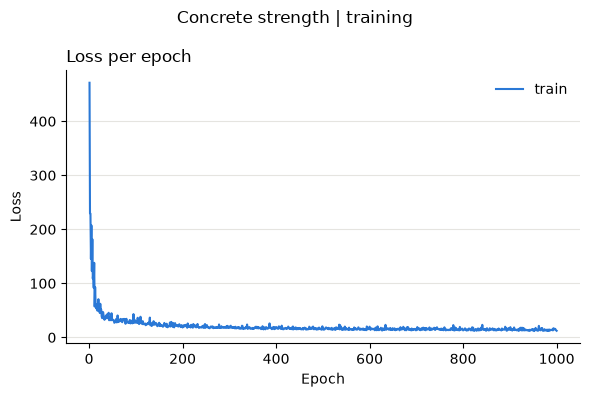

In [4]:
BATCH_SIZE = 32
LEARNING_RATE = 0.003
EPOCHS = 1000
PRINT_INTERVAL = 100

loader = DataLoader(x_set, y_set, batch_size=BATCH_SIZE, shuffle=True)

# a regressor: no accuracy to measure, only the MSE
trainer = Trainer(model, COSTS.MSE, learning_rate=LEARNING_RATE, classifier=False)
trainer.train(loader, epochs=EPOCHS, print_interval=PRINT_INTERVAL)

plot_history(trainer.history, title="Concrete strength | training")

### Against the baseline

In [5]:
bias = y_set.mean()
bias_pred = np.full_like(y_set, bias)
bias_mse = COSTS.MSE.function(bias_pred, y_set)

train_pred = model.forward(x_set)
train_mse = COSTS.MSE.function(train_pred, y_set)

# Test set (standardized with the training mean/std)
test_df = pd.read_csv(DATA_DIR / "concrete" / "test.csv")
x_test = test_df.iloc[:, :-1].to_numpy()
y_test = test_df.iloc[:, [-1]].to_numpy()
x_test = (x_test - features.to_numpy().mean(axis=0)) / features.to_numpy().std(axis=0)

bias_test_mse = COSTS.MSE.function(np.full_like(y_test, bias), y_test)
test_mse = COSTS.MSE.function(model.forward(x_test), y_test)

print(f"Bias (mean) prediction: {bias:.2f}")
print(f"Bias regressor MSE:     {bias_mse:.2f} (train) | {bias_test_mse:.2f} (test)")
print(f"Neural network MSE:     {train_mse:.2f} (train) | {test_mse:.2f} (test)")

Bias (mean) prediction: 36.19
Bias regressor MSE:     275.61 (train) | 286.01 (test)
Neural network MSE:     10.56 (train) | 31.51 (test)


## Implementation notes

### How backpropagation works

The backpropagation algorithm calculates the gradient of the cost in respect to every weight and bias in the model, then decreases the trainable parameters (weights and biases). In the train method, it starts a loop in which it goes through each layer and stores the last input and activation output. Then, it goes backwards, computing the gradients for each layer (derivative of loss) in respect to the weights, using the chain rule to push back the delta that was computed to the previous layer multiplied by the transposed weight. Lastly, at every layer, computed weight gradient and bias gradient from the backward is used to change the weight and bias of the layer. This is efficient because instead of calculating the chain rule separately for every weight, looping through extra for loop, each layer's delta calculate once and is reused for all of the weights in all of the layers.

### Design decisions

- Mini-batches are used, like the PyTorch version in Fundamentals 6, instead of single-sample steps (batch size
  32). A batch size of 1 still works and is the single-sample case.
- The architecture is 8 inputs → 16 hidden nodes → 8 hidden nodes → 1 output node, with ReLU on the hidden
  layers and identity (linear) on the output, since this is a regression problem.
- Weights are initialized uniformly in [−1, 1] and biases start at 0.
- Training uses learning rate 0.003, 1000 epochs, and data shuffled every epoch (like the PyTorch data
  loader). These were picked by trial and error.

### What I learned

- Getting the matrix shapes correct for the backward and step was the hardest part. In which, when implementing the code, writing the shape on a separate paper for each step of code made the formulas much clearer to me.
- The forward pass has to cache the values of each layer's input and output, so the backward pass can use them. This made it clear why backprop trades memory for speed.
- In training, the hyperparameters matter a lot. With a learning rate that was too large the loss blew up or oscillated, and with one that was too small it barely moved in 1000 epochs.

### A bug worth remembering

The biggest bug during the implementation was with the shapes of the weight gradients. I stored the W as the shape of (output_size, input_size), but at first I computed the weight gradient as dz @ last_input, which gives ((B, out) @ (B, in)). For some layers this crashed with a broadcasting error in step(), and for others (when the shapes happened to line up) it silently updated the wrong weights, and the loss did not go down. To fix it, I wrote out the shape of every array in step and backward for one batch (x: (B, in), W: (out, in), z: (B, out), dz: (B, out)). From that it was clear that the gradient has to have the same shape as W, so it must be dz.T @ last_input → (out, in).

### Use of AI tools

I used an AI assistant (Claude) to help run a numerical gradient check on my backward pass, to check the matrix
shapes in the NumPy calculations, and to generate the plotting code in the reporter. I also used it to format
the comparison against the simple bias regressor. The network and training code (now `numpy_nn` and
`numpy_trainer`) is my own implementation.

### Evidence of correctness

- **The loss goes down.** The training MSE is 27.6 at epoch 100, 15.3 at epoch 500 and 12.3 at epoch 1000,
  and the plotted curve trends downward. It is noisy from one print to the next because it is measured on
  shuffled mini-batches while the weights are still changing.
- **The network beats the baseline by far.** Always predicting the mean gives an MSE of 275.6 on the training
  set and 286.0 on `data/concrete/test.csv`. After training, the network reaches 10.6 (train) and 31.5 (test).
  The gap between the two shows some overfitting, but the network has clearly learned the relationship.
- **The gradients are right.** `tests/test_gradients.py` compares every weight and bias gradient from the
  backward pass with a finite-difference estimate $(C(\theta + \epsilon) - C(\theta - \epsilon)) / 2\epsilon$.
- **Shapes are checked.** `Layer.build` raises an error if any weight or bias has the wrong shape (I used Claude
  to double-check these checks).